**Install Required Libraries in Google Colab**

In [1]:
!pip install prophet xgboost holidays fastapi uvicorn nest-asyncio --quiet

**Upload Dataset**

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Copy of Forecasting Case- Study.xlsx to Copy of Forecasting Case- Study.xlsx


**Import Libraries**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [7]:
df = pd.read_excel("Copy of Forecasting Case- Study.xlsx")

In [8]:
df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages


**Data Preprocessing**

In [9]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Remove spaces from Total column if needed
df['Total'] = df['Total'].astype(str).str.replace(',', '')
df['Total'] = df['Total'].astype(float)

# Sort values
df = df.sort_values(['State', 'Date'])

# Check missing values
print(df.isnull().sum())

State       0
Date        0
Total       0
Category    0
dtype: int64


**Select One State for Initial Testing**

In [10]:
state_df = df[df['State'] == 'Texas'].copy()

**Set Date as Index**

In [11]:
state_df.set_index('Date', inplace=True)

# Weekly aggregation
state_df = state_df.resample('W').sum()

state_df.head()

,State,Total,Category
Date,,,
2019-01-13,Texas,472848726.3,Beverages
2019-01-20,0,0.0,0
2019-01-27,0,0.0,0
2019-02-03,0,0.0,0
2019-02-10,0,0.0,0


**Handle Missing Values**

In [12]:
state_df['Total'] = state_df['Total'].interpolate()

**Feature Engineering**

In [13]:
state_df['lag_1'] = state_df['Total'].shift(1)
state_df['lag_7'] = state_df['Total'].shift(7)
state_df['lag_30'] = state_df['Total'].shift(30)

**Rolling Mean and Std**

In [14]:
state_df['rolling_mean_7'] = state_df['Total'].rolling(7).mean()
state_df['rolling_std_7'] = state_df['Total'].rolling(7).std()

**Date Features**

In [15]:
state_df['month'] = state_df.index.month
state_df['dayofweek'] = state_df.index.dayofweek

**Drop Null Values**

In [16]:
state_df.dropna(inplace=True)

**Train Validation Split**

In [17]:
train_size = int(len(state_df) * 0.8)

train = state_df.iloc[:train_size]
test = state_df.iloc[train_size:]

**Evaluation Function**

In [18]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, rmse, mape

***MODEL 1 — SARIMA***

**Train SARIMA**

In [19]:
sarima_model = SARIMAX(
    train['Total'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()


**Predict**

In [20]:
sarima_pred = sarima_result.forecast(len(test))

**Evaluate**

In [21]:
sarima_metrics = evaluate(test['Total'], sarima_pred)

print("SARIMA Metrics:")
print(sarima_metrics)

SARIMA Metrics:
(666104132.9818059, np.float64(757545309.4278922), np.float64(inf))


***MODEL 2 — PROPHET***

**Prepare Prophet Data**

In [22]:
prophet_df = state_df.reset_index()[['Date', 'Total']]
prophet_df.columns = ['ds', 'y']

**Split Prophet Data**

In [23]:
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

**Train Prophet**

In [24]:
prophet_model = Prophet()

prophet_model.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


**Future Prediction**

In [25]:
future = prophet_model.make_future_dataframe(periods=len(test_prophet), freq='W')

forecast = prophet_model.predict(future)

**Get Predictions**

In [26]:
prophet_pred = forecast['yhat'].iloc[-len(test_prophet):].values

**Evaluate Prophet**

In [27]:
prophet_metrics = evaluate(test_prophet['y'], prophet_pred)

print("Prophet Metrics:")
print(prophet_metrics)

Prophet Metrics:
(817782585.3136122, np.float64(922506666.1857063), np.float64(inf))


***MODEL 3 — XGBOOST***

**Prepare Features**

In [28]:
features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'month',
    'dayofweek'
]

X_train = train[features]
y_train = train['Total']

X_test = test[features]
y_test = test['Total']

**Train XGBoost**

In [29]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

**Predict**

In [30]:
xgb_pred = xgb_model.predict(X_test)

**Evaluate**

In [31]:
xgb_metrics = evaluate(y_test, xgb_pred)

print("XGBoost Metrics:")
print(xgb_metrics)

XGBoost Metrics:
(498261242.1826087, np.float64(591366748.5381379), np.float64(inf))


***MODEL 4 — LSTM***

**Prepare LSTM Data**

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(state_df[['Total']])

**Create Sequences**

In [33]:
X = []
y = []

sequence_length = 5

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

**Split Data**

In [34]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

**Build LSTM Model**

In [35]:
lstm_model = Sequential()

lstm_model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

**Train LSTM**

In [36]:
lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=8,
    verbose=1
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0602
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0286 
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0226 
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0224 
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0220 
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0220 
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0219 
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0224 
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0218 
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0217 
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0218 
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0218 
Epoch 13/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0214 
Epoch 14/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0214 
Epoch 15/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0212
Epoch 

**Predict**

In [37]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


**Evaluate**

In [38]:
lstm_metrics = evaluate(y_test_actual, lstm_pred)

print("LSTM Metrics:")
print(lstm_metrics)

LSTM Metrics:
(455185683.5088889, np.float64(517081734.2375477), np.float64(inf))


***Compare Models***

In [39]:
results = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost', 'LSTM'],
    'RMSE': [
        sarima_metrics[1],
        prophet_metrics[1],
        xgb_metrics[1],
        lstm_metrics[1]
    ]
})

results

,Model,RMSE
0,SARIMA,7.575453e+08
1,Prophet,9.225067e+08
2,XGBoost,5.913667e+08
3,LSTM,5.170817e+08


***Select Best Model***

In [40]:
best_model = results.loc[results['RMSE'].idxmin()]

print("Best Model:")
print(best_model)

Best Model:
Model                LSTM
RMSE     517081734.237548
Name: 3, dtype: object


***Forecast Next 8 Weeks***

In [41]:
future_8 = prophet_model.make_future_dataframe(periods=8, freq='W')

forecast_8 = prophet_model.predict(future_8)

forecast_8[['ds', 'yhat']].tail(8)

,ds,yhat
180,2023-01-22,9.523140e+08
181,2023-01-29,1.147090e+09
182,2023-02-05,1.158124e+09
183,2023-02-12,1.020037e+09
184,2023-02-19,9.273506e+08
185,2023-02-26,1.008862e+09
186,2023-03-05,1.185694e+09
187,2023-03-12,1.270032e+09


***Plot Forecast***

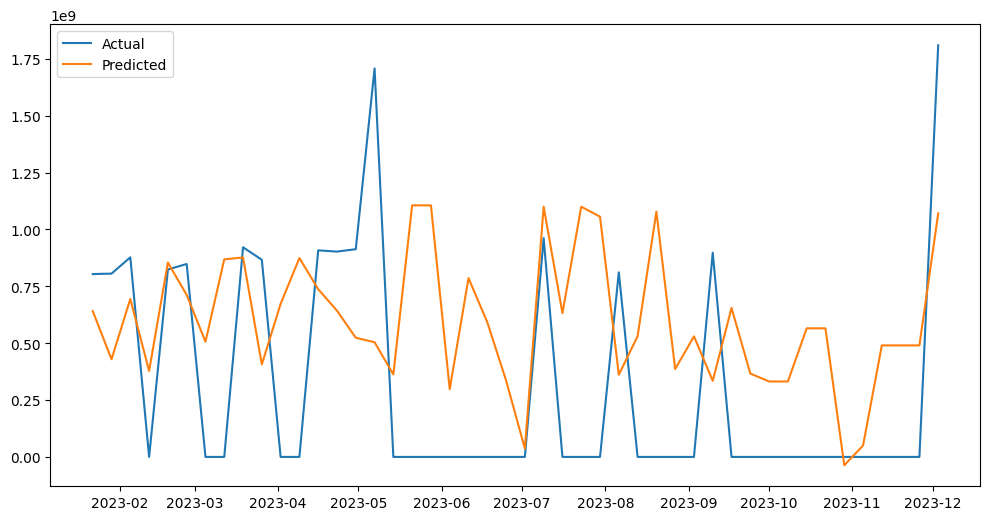

In [42]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Total'], label='Actual')
plt.plot(test.index, xgb_pred, label='Predicted')

plt.legend()
plt.show()

***FASTAPI SECTION***

**Save Model**

In [43]:
import joblib

joblib.dump(xgb_model, 'best_model.pkl')

['best_model.pkl']

**Create API File**

In [46]:
%%writefile app.py

from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()

model = joblib.load('best_model.pkl')

@app.get("/")
def home():
    return {"message": "Forecast API Running"}

@app.get("/predict")
def predict():

    sample = pd.DataFrame({
        'lag_1':[100],
        'lag_7':[110],
        'lag_30':[120],
        'rolling_mean_7':[115],
        'rolling_std_7':[5],
        'month':[5],
        'dayofweek':[2]
    })

    prediction = model.predict(sample)

    return {
        "forecast": prediction.tolist()
    }

Writing app.py


In [65]:
import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI
from pyngrok import ngrok
import uvicorn

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Forecast API Running"}

@app.get("/predict")
def predict():
    return {"forecast": [12345.67]}

# Add your ngrok auth token
ngrok.set_auth_token("33pyU8XWfrN8JFX8kwzY8Uf1j7s_612rotnaQX2f58dq3n8Ez")

# Create public URL
public_url = ngrok.connect(8000)

print("Public URL:", public_url)



Public URL: NgrokTunnel: "https://nonmultiplicative-iva-stumpy.ngrok-free.dev" -> "http://localhost:8000"


**Run API**

In [ ]:
!uvicorn app:app --host 0.0.0.0 --port 8000

INFO:     Started server process [15472]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     103.149.59.141:0 - "GET / HTTP/1.1" 200 OK
INFO:     103.149.59.141:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     103.149.59.141:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     103.149.59.141:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     103.149.59.141:0 - "GET /predict HTTP/1.1" 200 OK
